In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["svg.fonttype"] = "none"

In [3]:
md = pd.read_csv("data/metadata_boxplot_data_all_figureS7_ptype_Sep2026.csv")

# The pausing index columns this figure needs, one per timepoint.
PI_COLS = {
    "D8L4Y_0h": "log2_pausing_ratio",
    "D8L4Y_90min": "log2_pausing_ratio_90min",
    "D8L4Y_8h": "log2_pausing_ratio_8h",
}
[c for c in PI_COLS.values() if c not in md.columns]

['log2_pausing_ratio_90min', 'log2_pausing_ratio_8h']

In [5]:
missing = [c for c in PI_COLS.values() if c not in md.columns]
if missing:
    pau = pd.read_csv("data/Degron_PolII_pausing_ratio_with_metatadata_ENSGid.csv")
    pau["log2_pausing_ratio"] = np.log2(pau["pausing_ratio"].replace(0, np.nan))
    wide = pau.pivot_table(
        index="gene_id", columns="condition", values="log2_pausing_ratio"
    ).rename(
        columns={
            "D8L4Y_0h": "log2_pausing_ratio",
            "D8L4Y_90min": "log2_pausing_ratio_90min",
            "D8L4Y_8h": "log2_pausing_ratio_8h",
        }
    )
    md = md.drop(columns=["log2_pausing_ratio"]).merge(
        wide[list(PI_COLS.values())], left_on="gene_id", right_index=True, how="left"
    )

In [6]:
# Long format for the ECDF, one row per gene x timepoint.
# No additional coverage filter: the gene set is the one fixed upstream in the S7 table.
pausing_ratio = (
    pd.concat(
        [
            md[["gene_id", col]]
            .rename(columns={col: "log2_pausing_ratio"})
            .assign(condition=cond)
            for cond, col in PI_COLS.items()
        ],
        ignore_index=True,
    )
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["log2_pausing_ratio"])
)

pausing_ratio.groupby("condition").size()

condition
D8L4Y_0h       9849
D8L4Y_8h       9849
D8L4Y_90min    9848
dtype: int64

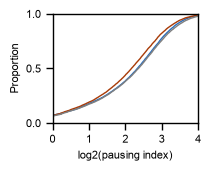

In [7]:
# plot ECDF of log2 pausing index for manuscript
sns.set_context("paper")

pal = sns.color_palette(["grey", "xkcd:rust", "xkcd:medium blue"])
condition_order = ["D8L4Y_0h", "D8L4Y_90min", "D8L4Y_8h"]

f, a = plt.subplots(figsize=(4, 1.8))

sns.ecdfplot(
    pausing_ratio,
    x="log2_pausing_ratio",
    hue="condition",
    hue_order=condition_order,
    palette=pal,
    linewidth=1,
    legend=False,
    ax=a,
)

a.set_box_aspect(0.75)

# The ECDF is computed over every gene in the table; the x-range below is a view,
# not a filter, so the curves do not start at zero. See the note printed in the next cell.
a.set_xlim(0, 4)
a.set_xlabel("log2(pausing index)", fontsize=8)

a.set_ylabel("Proportion", fontsize=8)
a.set_yticks([0, 0.5, 1])

a.tick_params(axis="both", labelsize=8)

f.tight_layout()

f.savefig("pausing_ratio_ECDF_0_1p5_8hr.svg")

In [8]:
# Proportion of each curve that lies left of the plotted range, i.e. the height at x = 0.
for cond in condition_order:
    v = pausing_ratio.query("condition == @cond").log2_pausing_ratio
    print(
        f"{cond:<12} n = {len(v):>5}   fraction with log2 pausing index <= 0: {(v <= 0).mean():.3f}"
    )

D8L4Y_0h     n =  9849   fraction with log2 pausing index <= 0: 0.064
D8L4Y_90min  n =  9848   fraction with log2 pausing index <= 0: 0.068
D8L4Y_8h     n =  9849   fraction with log2 pausing index <= 0: 0.069


In [9]:
# Fraction of genes above the highly-paused threshold quoted in the Results.
above_4 = pausing_ratio.query("condition == 'D8L4Y_0h' & log2_pausing_ratio > 4")
all_0h = pausing_ratio.query("condition == 'D8L4Y_0h'")
print(
    f"{above_4.shape[0]} / {all_0h.shape[0]} = {above_4.shape[0] / all_0h.shape[0]:.2%}"
)

210 / 9849 = 2.13%
